<a href="https://colab.research.google.com/github/Jeff-004/Projects/blob/main/Market_Making.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ── 1. Load ────────────────────────────────────────────────────────
df = pd.read_csv("trade_data.csv")

# ── 2. Clean
df = df.dropna(subset=['Name', 'Side'])
df = df[df['Name'].apply(lambda x: isinstance(x, str))]
df = df[df['Side'].apply(lambda x: isinstance(x, (int, float)))]
df['side_numeric'] = df['Side']

# ── 3. Tau to column mapping ───────────────────────────────────────
tau_col = {
    5:  'M5',
    10: 'M10',
    15: 'M15',
    20: 'M20',
    25: 'M25',
    30: 'M30'
}

# ── 4. Core function ───────────────────────────────────────────────
def adversity_profile(client: str, tau: List[int]) -> List[float]:

    client_df = df[df['Name'] == client].copy()

    result = []

    for t in tau:
        col = tau_col[t]

        # PnL = side x volume x (mid_at_tau - trade_price)
        pnl = (
            client_df['side_numeric'] *
            client_df['Volume'] *
            (client_df[col] - client_df['Trade Price'])
        )

        # Percentage of trades where PnL < 0
        adversity_pct = (pnl < 0).mean() * 100

        result.append(round(float(adversity_pct), 4))

    return result

clients = sorted([c for c in df['Name'].unique() if isinstance(c, str)])
taus = [5, 10, 15, 20, 25, 30]

print("\nClients found:", clients)

# ── 5. Build results table ─────────────────────────────────────────
rows = []
for client in clients:
    profile = adversity_profile(client, taus)
    rows.append([client] + profile)
    print(f"Client {client}: {profile}")

# ── 6. Save CSV ────────────────────────────────────────────────────
results = pd.DataFrame(
    rows,
    columns=['client', 'tau=5', 'tau=10', 'tau=15',
             'tau=20', 'tau=25', 'tau=30']
)

results.to_csv('task1_results.csv', index=False)

print("\nFinal Results:")
print(results)
print("\nSaved to task1_results.csv")


Clients found: ['A', 'B', 'C', 'D', 'E', 'F']
Client A: [39.6229, 41.2354, 42.1478, 41.8834, 41.9008, 41.7265]
Client B: [40.911, 42.4088, 43.0637, 43.1772, 43.3133, 43.0896]
Client C: [41.3267, 43.5263, 44.2178, 44.7182, 45.3332, 45.917]
Client D: [43.3663, 46.5016, 48.1329, 49.6368, 50.4652, 51.5612]
Client E: [44.9756, 48.5468, 51.0804, 52.1483, 53.8458, 54.7726]
Client F: [46.8694, 51.6763, 54.1352, 56.8328, 59.536, 61.9172]

Final Results:
  client    tau=5   tau=10   tau=15   tau=20   tau=25   tau=30
0      A  39.6229  41.2354  42.1478  41.8834  41.9008  41.7265
1      B  40.9110  42.4088  43.0637  43.1772  43.3133  43.0896
2      C  41.3267  43.5263  44.2178  44.7182  45.3332  45.9170
3      D  43.3663  46.5016  48.1329  49.6368  50.4652  51.5612
4      E  44.9756  48.5468  51.0804  52.1483  53.8458  54.7726
5      F  46.8694  51.6763  54.1352  56.8328  59.5360  61.9172

Saved to task1_results.csv


In [5]:
# ── 1. Expected PnL function ───────────────────────────────────────
def expected_pnl(client: str, tau: List[int]) -> dict:
    client_df = df[df['Name'] == client].copy()

    per_horizon = []
    all_pnls = []

    for t in tau:
        col = tau_col[t]

        # PnL per trade at this horizon
        pnl = (
            client_df['side_numeric'] *
            client_df['Volume'] *
            (client_df[col] - client_df['Trade Price'])
        )

        expected = float(pnl.mean())
        per_horizon.append(round(expected, 6))
        all_pnls.append(pnl)

    pnl_matrix = pd.concat(all_pnls, axis=1)
    aggregate_per_trade = pnl_matrix.mean(axis=1)
    aggregate = round(float(aggregate_per_trade.mean()), 6)

    return {
        'per_horizon': per_horizon,
        'aggregate': aggregate
    }

# ── 2. Classify client ─────────────────────────────────────────────
def classify_client(client: str) -> str:
    """
    Returns 'profitable' if aggregate expected PnL >= 0
    Returns 'costly' if aggregate expected PnL < 0
    """
    result = expected_pnl(client, [5, 10, 15, 20, 25, 30])
    if result['aggregate'] >= 0:
        return 'profitable'
    else:
        return 'costly'

# ── 3. Minimum half-spread ─────────────────────────────────────────
def min_half_spread(client: str) -> float:
    """
    New PnL = side x volume x (M_tau - M0) + volume x delta
    To break even,
    delta* = -original_aggregate_pnl / mean(volume)
    """
    client_df = df[df['Name'] == client].copy()

    result = expected_pnl(client, [5, 10, 15, 20, 25, 30])
    agg_pnl = result['aggregate']

    if agg_pnl >= 0:
        return 0.0

    mean_volume = float(client_df['Volume'].mean())
    delta_star = -agg_pnl / mean_volume

    return round(delta_star, 6)

# ── 4. Run for all clients ─────────────────────────────────────────
clients = sorted([c for c in df['Name'].unique() if isinstance(c, str)])
taus = [5, 10, 15, 20, 25, 30]

print("Running Task 2...\n")

rows = []
for client in clients:
    result = expected_pnl(client, taus)
    agg = result['aggregate']
    delta = min_half_spread(client)
    classification = classify_client(client)

    row = [client] + result['per_horizon'] + [agg, delta]
    rows.append(row)

    print(f"Client {client}: agg_pnl={agg:.4f}, "
          f"delta*={delta:.6f}, classification={classification}")

# ── 5. Save CSV ────────────────────────────────────────────────────
results = pd.DataFrame(
    rows,
    columns=['client', 'tau=5', 'tau=10', 'tau=15',
             'tau=20', 'tau=25', 'tau=30', 'agg_pnl', 'delta*']
)

results.to_csv('task2_results.csv', index=False)

print("\nFinal Results:")
print(results)
print("\nSaved to task2_results.csv")

Running Task 2...

Client A: agg_pnl=1.9170, delta*=0.000000, classification=profitable
Client B: agg_pnl=1.6628, delta*=0.000000, classification=profitable
Client C: agg_pnl=1.1493, delta*=0.000000, classification=profitable
Client D: agg_pnl=0.3220, delta*=0.000000, classification=profitable
Client E: agg_pnl=-0.3934, delta*=0.005247, classification=costly
Client F: agg_pnl=-1.4458, delta*=0.019357, classification=costly

Final Results:
  client     tau=5    tau=10    tau=15    tau=20    tau=25    tau=30  \
0      A  1.286907  1.566450  1.764530  2.080565  2.305067  2.498448   
1      B  1.214955  1.362707  1.567184  1.771690  1.955779  2.104788   
2      C  1.056355  1.135512  1.176512  1.145534  1.201228  1.180814   
3      D  0.869487  0.696726  0.514670  0.210661 -0.042448 -0.317280   
4      E  0.654351  0.303356 -0.117360 -0.563153 -1.054122 -1.583579   
5      F  0.433311 -0.175914 -0.897516 -1.775006 -2.627125 -3.632736   

    agg_pnl    delta*  
0  1.916995  0.000000  
1  1

In [6]:
# ── 1. Parse datetime ──────────────────────────────────────────────
df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['time'].astype(str))
df = df.sort_values('datetime').reset_index(drop=True)

# ── 2. Feature engineering ─────────────────────────────────────────
client_map = {c: i for i, c in enumerate(sorted(df['Name'].unique()))}
# e.g. {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
print("Client mapping:", client_map)

df['client_encoded'] = df['Name'].map(client_map)

# Price offset - normalized
df['price_offset'] = (df['Trade Price'] - df['M0']) / df['M0']

# Spread - normalized
df['spread_normalized'] = df['Spread'] / df['M0']

# Log volume
df['log_volume'] = np.log(df['Volume'])

# Time features
df['hour'] = pd.to_datetime(df['time'].astype(str)).dt.hour
df['minute'] = pd.to_datetime(df['time'].astype(str)).dt.minute

# ── 3. Define feature columns ──────────────────────────────────────
feature_cols = [
    'client_encoded',    # 0: which client
    'side_numeric',      # 1: LP buy (+1) or sell (-1)
    'log_volume',        # 2: log of trade volume
    'price_offset',      # 3: (Trade Price - M0) / M0
    'spread_normalized', # 4: Spread / M0
    'hour',              # 5: hour of trade
    'minute',            # 6: minute of trade
]

# ── 4. Build targets for each tau ──────────────────────────────────
for t, col in tau_col.items():
    pnl = (
        df['side_numeric'] *
        df['Volume'] *
        (df[col] - df['Trade Price'])
    )
    df[f'adverse_{t}'] = (pnl < 0).astype(int)

print("Adverse rate per tau (overall):")
for t in [5, 10, 15, 20, 25, 30]:
    print(f"  tau={t}: {df[f'adverse_{t}'].mean():.4f}")

# ── 5. Train/Val/Test split — by DATE ──────────────
# 60% train, 20% val, 20% test
n = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f"\nSplit sizes — Train: {len(train_df)}, "
      f"Val: {len(val_df)}, Test: {len(test_df)}")

X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

# ── 6. Train one model per tau ─────────────────────────────────────
taus = [5, 10, 15, 20, 25, 30]
models = {}

for t in taus:
    y_train = train_df[f'adverse_{t}']

    model = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        min_child_samples=20,
        random_state=42,
        verbose=-1
    )

    model.fit(X_train, y_train)
    models[t] = model
    print(f"Trained model for tau={t}")

# ── 7. Compute metrics ─────────────────────────────────────────────
def compute_metrics() -> pd.DataFrame:
    splits = {
        'train':      (X_train, train_df),
        'validation': (X_val,   val_df),
        'test':       (X_test,  test_df)
    }

    results = []

    for split_name, (X, split_df) in splits.items():
        acc_list, prec_list, rec_list, ll_list = [], [], [], []

        for t in taus:
            y_true = split_df[f'adverse_{t}']
            y_pred_proba = models[t].predict_proba(X)[:, 1]
            y_pred_label = (y_pred_proba >= 0.5).astype(int)

            acc_list.append(accuracy_score(y_true, y_pred_label))
            prec_list.append(precision_score(y_true, y_pred_label,
                                             zero_division=0))
            rec_list.append(recall_score(y_true, y_pred_label,
                                         zero_division=0))
            ll_list.append(log_loss(y_true, y_pred_proba))

        results.append({
            'split':     split_name,
            'accuracy':  round(np.mean(acc_list), 4),
            'precision': round(np.mean(prec_list), 4),
            'recall':    round(np.mean(rec_list), 4),
            'log_loss':  round(np.mean(ll_list), 4)
        })

    return pd.DataFrame(results).set_index('split')

metrics_df = compute_metrics()
print("\nMetrics:")
print(metrics_df)

# ── 8. Prediction function ─────────────────────────────────────────
def predict_adversity(client: str, features: list, tau: int) -> float:
    X = pd.DataFrame([features], columns=feature_cols)
    prob = models[tau].predict_proba(X)[0, 1]
    return float(prob)

# ── 9. Save metrics CSV ───────────────────────────────────────────
metrics_df.to_csv('task3_results.csv')
print("\nSaved to task3_results.csv")
print("\nFeature vector order:")
for i, col in enumerate(feature_cols):
    print(f"  {i}: {col}")

Client mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
Adverse rate per tau (overall):
  tau=5: 0.4228
  tau=10: 0.4483
  tau=15: 0.4615
  tau=20: 0.4688
  tau=25: 0.4768
  tau=30: 0.4827

Split sizes — Train: 93268, Val: 31090, Test: 31090
Trained model for tau=5
Trained model for tau=10
Trained model for tau=15
Trained model for tau=20
Trained model for tau=25
Trained model for tau=30

Metrics:
            accuracy  precision  recall  log_loss
split                                            
train         0.5696     0.5802  0.2674    0.6784
validation    0.5555     0.5251  0.2540    0.6853
test          0.5580     0.5209  0.2553    0.6846

Saved to task3_results.csv

Feature vector order:
  0: client_encoded
  1: side_numeric
  2: log_volume
  3: price_offset
  4: spread_normalized
  5: hour
  6: minute


Splits recreated. Val size: 31090 Test size: 31090
Sweeping theta for each tau...

tau= 5: theta*=0.59, val_pnl=29956.6539, test_pnl=31909.9469
tau=10: theta*=0.65, val_pnl=28829.6084, test_pnl=31882.9038
tau=15: theta*=0.51, val_pnl=28761.2954, test_pnl=30858.5808
tau=20: theta*=0.48, val_pnl=30925.5831, test_pnl=30258.9632
tau=25: theta*=0.50, val_pnl=34433.8109, test_pnl=32129.5160
tau=30: theta*=0.48, val_pnl=36076.5798, test_pnl=34118.7033


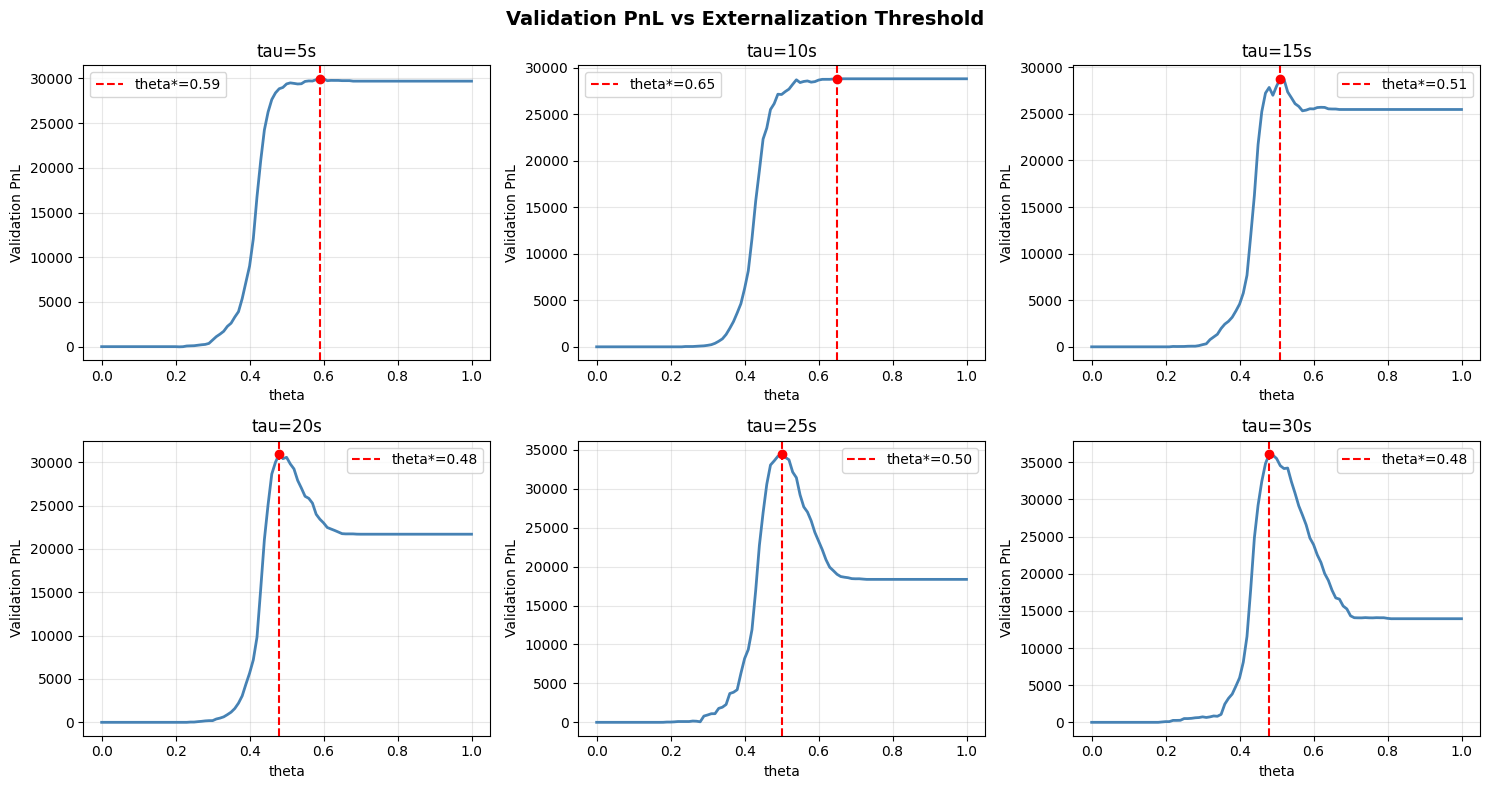

Saved to pnl_vs_theta.png

Checking client-specific optimal thresholds...

Client-specific theta* per tau:
Client    tau=5     tau=10    tau=15    tau=20    tau=25    tau=30    
A         0.55      0.57      0.55      0.51      0.53      0.52      
B         0.59      0.54      0.52      0.56      0.49      0.60      
C         0.62      0.65      0.62      0.58      0.55      0.58      
D         0.61      0.60      0.60      0.63      0.36      0.47      
E         0.47      0.64      0.00      0.40      0.41      0.00      
F         0.58      0.42      0.42      0.44      0.00      0.00      

Saved to task4_results.csv
   client  tau  theta*   final_pnl
0       A    5    0.55   9628.2938
1       A   10    0.57  12430.5314
2       A   15    0.55  12534.7532
3       A   20    0.51  14252.9628
4       A   25    0.53  15755.5927
5       A   30    0.52  16840.6998
6       B    5    0.59   6987.8653
7       B   10    0.54   9161.0118
8       B   15    0.52   9570.9428
9       B   20    

In [7]:
# ── 1. Add pnl columns to df ───────────────────────────────────────
for t, col in tau_col.items():
    df[f'pnl_{t}'] = (
        df['side_numeric'] *
        df['Volume'] *
        (df[col] - df['Trade Price'])
    )

# ── 2. Recreate splits and recompute probabilities─────────────────
n = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df   = df.iloc[train_end:val_end].reset_index(drop=True)
test_df  = df.iloc[val_end:].reset_index(drop=True)

X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

val_probas  = {}
test_probas = {}

for t in taus:
    val_probas[t]  = models[t].predict_proba(X_val)[:, 1]
    test_probas[t] = models[t].predict_proba(X_test)[:, 1]

print("Splits recreated. Val size:", len(val_df),
      "Test size:", len(test_df))

# ── 3. PnL under externalization strategy ─────────────────────────
def compute_pnl_at_theta(theta: float, tau: int,
                          probas: np.ndarray,
                          pnl_series: pd.Series) -> float:

    # True = internalize, False = externalize
    internalize_mask = probas <= theta

    total_pnl = pnl_series[internalize_mask].sum()
    return float(total_pnl)


# ── 4. Sweep theta for each tau ────────────────────────────────────
theta_grid = np.linspace(0, 1, 101)

optimal_thresholds = {}
val_pnls_at_optimal = {}
test_pnls_at_optimal = {}
all_val_pnl_curves = {}

print("Sweeping theta for each tau...\n")

for t in taus:
    val_pnl_curve = []

    pnl_val_series  = val_df[f'pnl_{t}'].reset_index(drop=True)
    pnl_test_series = test_df[f'pnl_{t}'].reset_index(drop=True)

    for theta in theta_grid:
        pnl = compute_pnl_at_theta(
            theta, t, val_probas[t], pnl_val_series
        )
        val_pnl_curve.append(pnl)

    all_val_pnl_curves[t] = val_pnl_curve

    # Find theta that maximizes validation PnL
    best_idx   = np.argmax(val_pnl_curve)
    theta_star = theta_grid[best_idx]
    best_val_pnl = val_pnl_curve[best_idx]

    # Apply theta* to test set
    best_test_pnl = compute_pnl_at_theta(
        theta_star, t, test_probas[t], pnl_test_series
    )

    optimal_thresholds[t]    = theta_star
    val_pnls_at_optimal[t]   = best_val_pnl
    test_pnls_at_optimal[t]  = best_test_pnl

    print(f"tau={t:2d}: theta*={theta_star:.2f}, "
          f"val_pnl={best_val_pnl:.4f}, "
          f"test_pnl={best_test_pnl:.4f}")

# ── 5. Plot PnL vs theta for all taus ─────────────────────────────
def plot_pnl_vs_theta():
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for idx, t in enumerate(taus):
        ax = axes[idx]
        ax.plot(theta_grid, all_val_pnl_curves[t],
                color='steelblue', linewidth=2)

        theta_star = optimal_thresholds[t]
        best_pnl   = val_pnls_at_optimal[t]
        ax.axvline(x=theta_star, color='red',
                   linestyle='--', label=f'theta*={theta_star:.2f}')
        ax.scatter([theta_star], [best_pnl],
                   color='red', zorder=5)

        ax.set_title(f'tau={t}s', fontsize=12)
        ax.set_xlabel('theta')
        ax.set_ylabel('Validation PnL')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Validation PnL vs Externalization Threshold',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('pnl_vs_theta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to pnl_vs_theta.png")

plot_pnl_vs_theta()

# ── 6. Client-specific thresholds ─────────────────────────────────
print("\nChecking client-specific optimal thresholds...")

client_thresholds = {}  # {(client, tau): theta*}

for client in sorted(df['Name'].unique()):
    client_val_idx  = val_df[val_df['Name'] == client].index
    client_test_idx = test_df[test_df['Name'] == client].index

    # Map to positional indices within val/test arrays
    val_positions  = [val_df.index.get_loc(i)
                      for i in client_val_idx
                      if i in val_df.index]
    test_positions = [test_df.index.get_loc(i)
                      for i in client_test_idx
                      if i in test_df.index]

    if len(val_positions) == 0:
        continue

    for t in taus:
        c_val_probas  = val_probas[t][val_positions]
        c_val_pnl     = val_df[f'pnl_{t}'].iloc[val_positions]\
                            .reset_index(drop=True)

        c_val_curve = []
        for theta in theta_grid:
            pnl = compute_pnl_at_theta(
                theta, t, c_val_probas, c_val_pnl
            )
            c_val_curve.append(pnl)

        best_idx = np.argmax(c_val_curve)
        client_thresholds[(client, t)] = theta_grid[best_idx]

print("\nClient-specific theta* per tau:")
print(f"{'Client':<10}", end="")
for t in taus:
    print(f"tau={t:<6}", end="")
print()

for client in sorted(df['Name'].unique()):
    print(f"{client:<10}", end="")
    for t in taus:
        theta = client_thresholds.get((client, t), float('nan'))
        print(f"{theta:<10.2f}", end="")
    print()

# ── 7. Save task4_results.csv ──────────────────────────────────────
rows = []
for client in sorted(df['Name'].unique()):
    for t in taus:
        theta_star = client_thresholds.get((client, t),
                                           optimal_thresholds[t])

        # Test PnL for this client at this tau
        client_test_idx = test_df[test_df['Name'] == client].index
        test_positions  = [test_df.index.get_loc(i)
                           for i in client_test_idx
                           if i in test_df.index]

        if len(test_positions) > 0:
            c_test_probas = test_probas[t][test_positions]
            c_test_pnl    = test_df[f'pnl_{t}'].iloc[test_positions]\
                                .reset_index(drop=True)
            final_pnl = compute_pnl_at_theta(
                theta_star, t, c_test_probas, c_test_pnl
            )
        else:
            final_pnl = 0.0

        rows.append({
            'client':    client,
            'tau':       t,
            'theta*':    round(theta_star, 2),
            'final_pnl': round(final_pnl, 4)
        })

task4_df = pd.DataFrame(rows)
task4_df.to_csv('task4_results.csv', index=False)
print("\nSaved to task4_results.csv")
print(task4_df)

def optimal_threshold(tau: int) -> dict:
    return {
        'theta':          optimal_thresholds[tau],
        'validation_pnl': val_pnls_at_optimal[tau],
        'test_pnl':       test_pnls_at_optimal[tau]
    }

print("\nGlobal optimal thresholds:")
for t in taus:
    result = optimal_threshold(t)
    print(f"tau={t}: {result}")

Dynamic Quoting Function

delta* (min half-spread) per client:
  Client A: 0.000000
  Client B: 0.000000
  Client C: 0.000000
  Client D: 0.000000
  Client E: 0.005247
  Client F: 0.019357

Test set size: 31090 trades
Alpha (mean over taus) — mean=0.4597, std=0.0492

  TASK 5 BACKTEST — TEST SET
  Total trades     : 31090
  Internalized     : 30602  (98.4%)
  Externalized     : 488  (1.6%)
  Total PnL        : 74,250.0207
  Avg Daily PnL    : 8,250.0023
  Std Daily PnL    : 4,371.4513
  Sharpe-like      : 16.9852
  Max Drawdown     : 0.0000

Per-client internalized PnL breakdown:
        n_trades   total_pnl  avg_pnl  avg_delta
client                                          
A           6862  23908.0392   3.4841     0.0345
B           6180  19880.2545   3.2169     0.0344
C           5749  15427.5140   2.6835     0.0348
D           4649   8657.5047   1.8622     0.0348
E           3552   4767.0993   1.3421     0.0362
F           3610   1609.6052   0.4459     0.0388


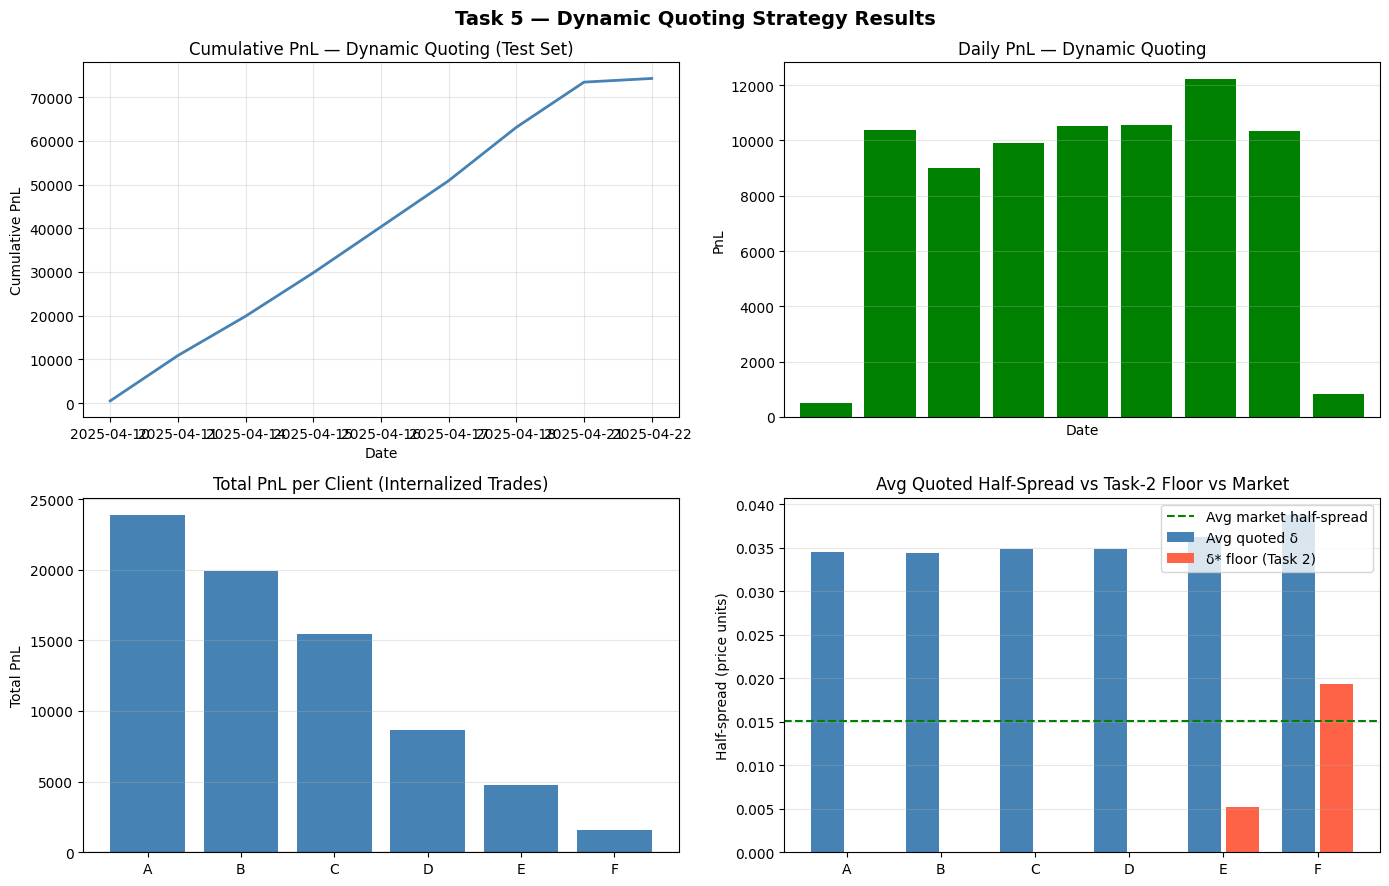

Saved task5_backtest.png
Saved task5_results.csv


In [10]:
delta_star_per_client = {}
for client in clients:
    delta_star_per_client[client] = min_half_spread(client)

print("delta* (min half-spread) per client:")
for c, d in delta_star_per_client.items():
    print(f"  Client {c}: {d:.6f}")

data = test_df.copy().reset_index(drop=True)

# Realized mid-price volatility — rolling 20-trade window
data['mid_return'] = data['M0'].pct_change().fillna(0)
returns_arr = data['mid_return'].values

sigmas = []
for i in range(len(returns_arr)):
    window = returns_arr[max(0, i - 20):i]
    if len(window) < 2:
        sigmas.append(max(abs(returns_arr[i]), 1e-6))
    else:
        sigmas.append(float(np.sqrt(np.mean(window ** 2))))
data['sigma'] = np.clip(sigmas, 1e-6, None)

# Elapsed day fraction eta ∈ [0, 1]
data['time_dt'] = pd.to_datetime(data['time'].astype(str))
for date, grp in data.groupby('Date'):
    t0   = grp['time_dt'].min()
    t1   = grp['time_dt'].max()
    span = (t1 - t0).total_seconds()
    if span == 0:
        data.loc[grp.index, 'eta'] = 0.5
    else:
        data.loc[grp.index, 'eta'] = (
            (grp['time_dt'] - t0).dt.total_seconds() / span
        )

# Pre-compute adversity probabilities
#   alpha_mat[i, j] = P(adverse | row i, taus[j])
X_data = data[feature_cols]
alpha_mat = np.column_stack([
    models[t].predict_proba(X_data)[:, 1]
    for t in taus
])
data['alpha_mean'] = alpha_mat.mean(axis=1)

print(f"\nTest set size: {len(data)} trades")
print(f"Alpha (mean over taus) — mean={data['alpha_mean'].mean():.4f}, "
      f"std={data['alpha_mean'].std():.4f}")

K       = 1.5    # vol-scaling of base spread
GAMMA   = 0.3    # inventory skew strength
BETA    = 0.4    # adversity widening strength
ETA_K   = 2.0    # end-of-day urgency multiplier
C_MIN   = 0.5    # minimum spread as multiple of sigma
MAX_BPS = 50     # hard upper cap in basis points

def quote(inventory:    float,
          sigma:        float,
          alpha:        float,
          eta:          float,
          delta_floor:  float,
          mid:          float,
          market_half_spread: float) -> tuple:
    """
    Returns (delta_bid, delta_ask) — half-spreads in price units.

    delta_floor : client's minimum half-spread (delta* from Task 2)
    mid         : current mid price M0
    market_half_spread : half of the observed market Spread, used to
                          keep the quoted half-spread economically
                          anchored to where the market actually is
    """
    base          = K * sigma
    skew          = GAMMA * inventory * sigma
    adversity_adj = BETA * alpha * sigma
    eod_adj       = ETA_K * (eta ** 2) * abs(inventory) * sigma

    delta_bid = base + skew  + adversity_adj + eod_adj
    delta_ask = base - skew  + adversity_adj + eod_adj

    # Floor: max of Task-2 delta* and vol-based minimum
    lower = max(delta_floor, C_MIN * sigma)
    # Cap: tighter of (50 bps of current mid) and a multiple of the
    # actual observed market half-spread, so quotes can't drift to
    # many multiples of where the market really is
    upper = min(MAX_BPS / 10_000 * mid, 3 * market_half_spread)
    upper = max(upper, lower)

    delta_bid = float(np.clip(delta_bid, lower, upper))
    delta_ask = float(np.clip(delta_ask, lower, upper))

    return delta_bid, delta_ask

# ── 4. Backtest on test set ────────────────────────────────────────
#
#  Decision per trade per tau:
#    alpha_tau > theta*(client, tau)  →  EXTERNALIZE  (pnl contribution = 0)
#    alpha_tau <= theta*(client, tau) →  INTERNALIZE  (earn spread)

TAU_GATE = 5

records = []

inventory    = 0.0
current_date = None
day_pnl      = 0.0
daily_pnls   = {}
n_internalized = 0
n_externalized = 0

for i, row in data.iterrows():
    date   = row['Date']
    client = row['Name']
    side   = row['side_numeric']
    vol    = row['Volume']
    sigma  = row['sigma']
    eta    = row['eta']
    mid    = row['M0']
    alpha  = row['alpha_mean']
    market_half_spread = row['Spread'] / 2

    # ── Day boundary: close inventory, record day PnL ──────────────
    if date != current_date:
        if current_date is not None:
            daily_pnls[current_date] = day_pnl
        current_date = date
        day_pnl      = 0.0
        inventory    = 0.0          # inventory resets each day

    # ── Internalize / Externalize decision ─────────────────────────
    alpha_gate = alpha_mat[i, taus.index(TAU_GATE)]
    theta_gate = client_thresholds.get(
        (client, TAU_GATE),
        optimal_thresholds[TAU_GATE]
    )

    if alpha_gate > theta_gate:
        n_externalized += 1
        records.append({
            'date': date, 'client': client,
            'decision': 'externalize',
            'delta_bid': np.nan, 'delta_ask': np.nan,
            'trade_pnl': 0.0, 'inventory_after': inventory
        })
        continue

    n_internalized += 1

    # Dynamic spread, anchored to the actual market half-spread
    delta_floor = delta_star_per_client.get(client, 0.0)
    delta_bid, delta_ask = quote(inventory, sigma, alpha, eta,
                                  delta_floor, mid, market_half_spread)

    delta_side = delta_bid if side == 1 else delta_ask

    # PnL computed entirely from the desk's own quoted price, not the
    # historical Trade Price — no separate "spread_income" add-on
    quoted_price = mid - side * delta_side
    future_mids = np.array([row[tau_col[t]] for t in taus])
    avg_future_mid = future_mids.mean()
    trade_pnl = side * vol * (avg_future_mid - quoted_price)

    day_pnl   += trade_pnl
    inventory += side * vol

    records.append({
        'date':            date,
        'client':          client,
        'decision':        'internalize',
        'alpha':           round(alpha, 4),
        'alpha_gate':      round(alpha_gate, 4),
        'theta_gate':      round(theta_gate, 2),
        'sigma':           round(sigma, 8),
        'delta_bid':       round(delta_bid, 6),
        'delta_ask':       round(delta_ask, 6),
        'delta_side':      round(delta_side, 6),
        'quoted_price':    round(quoted_price, 6),
        'trade_pnl':       round(trade_pnl, 4),
        'inventory_after': round(inventory, 2)
    })

if current_date is not None:
    daily_pnls[current_date] = day_pnl

# Results
results_df      = pd.DataFrame(records)
internalized_df = results_df[results_df['decision'] == 'internalize'].copy()

daily_pnl_series = pd.Series(daily_pnls).sort_index()
total_pnl        = daily_pnl_series.sum()
avg_daily_pnl    = daily_pnl_series.mean()
std_daily_pnl    = daily_pnl_series.std()
sharpe           = total_pnl / max(std_daily_pnl, 1e-9)
cumulative       = daily_pnl_series.cumsum()
max_drawdown     = (cumulative - cumulative.cummax()).min()

print("\n" + "=" * 55)
print("  TASK 5 BACKTEST — TEST SET")
print("=" * 55)
print(f"  Total trades     : {len(data)}")
print(f"  Internalized     : {n_internalized}  "
      f"({100*n_internalized/len(data):.1f}%)")
print(f"  Externalized     : {n_externalized}  "
      f"({100*n_externalized/len(data):.1f}%)")
print(f"  Total PnL        : {total_pnl:,.4f}")
print(f"  Avg Daily PnL    : {avg_daily_pnl:,.4f}")
print(f"  Std Daily PnL    : {std_daily_pnl:,.4f}")
print(f"  Sharpe-like      : {sharpe:.4f}")
print(f"  Max Drawdown     : {max_drawdown:,.4f}")
print("=" * 55)

# Per-client breakdown
print("\nPer-client internalized PnL breakdown:")
client_summary = (
    internalized_df.groupby('client')
    .agg(
        n_trades    =('trade_pnl', 'count'),
        total_pnl   =('trade_pnl', 'sum'),
        avg_pnl     =('trade_pnl', 'mean'),
        avg_delta   =('delta_side', 'mean'),
    )
    .round(4)
)
print(client_summary.to_string())

# ── Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Cumulative PnL
ax = axes[0, 0]
daily_pnl_series.cumsum().plot(ax=ax, color='steelblue', linewidth=2)
ax.set_title('Cumulative PnL — Dynamic Quoting (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL')
ax.grid(True, alpha=0.3)

# (b) Daily PnL bar chart
ax = axes[0, 1]
colors = ['green' if v >= 0 else 'red' for v in daily_pnl_series]
daily_pnl_series.plot(kind='bar', ax=ax, color=colors, width=0.8)
ax.set_title('Daily PnL — Dynamic Quoting')
ax.set_xlabel('Date')
ax.set_ylabel('PnL')
ax.set_xticks([])
ax.grid(True, alpha=0.3, axis='y')

# (c) Per-client total PnL
ax = axes[1, 0]
x = np.arange(len(client_summary))
ax.bar(x, client_summary['total_pnl'], color='steelblue')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(client_summary.index)
ax.set_title('Total PnL per Client (Internalized Trades)')
ax.set_ylabel('Total PnL')
ax.grid(True, alpha=0.3, axis='y')

# (d) Avg quoted half-spread per client vs delta* floor and market half-spread
ax = axes[1, 1]
avg_deltas = client_summary['avg_delta'].values
delta_floors = [delta_star_per_client.get(c, 0) for c in client_summary.index]
market_hs = data['Spread'].mean() / 2
x = np.arange(len(client_summary))
ax.bar(x - 0.2, avg_deltas,    width=0.35, label='Avg quoted δ', color='steelblue')
ax.bar(x + 0.2, delta_floors,  width=0.35, label='δ* floor (Task 2)', color='tomato')
ax.axhline(market_hs, color='green', linestyle='--', label='Avg market half-spread')
ax.set_xticks(x)
ax.set_xticklabels(client_summary.index)
ax.set_title('Avg Quoted Half-Spread vs Task-2 Floor vs Market')
ax.set_ylabel('Half-spread (price units)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Task 5 — Dynamic Quoting Strategy Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task5_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved task5_backtest.png")

# ── Save results ────────────────────────────────────────────────
internalized_df.to_csv('task5_results.csv', index=False)
print("Saved task5_results.csv")